In [1]:
import torch
from torch import Tensor
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Vizualisation of the initial momentum sampler

We want to sample from the following probability density on the initial momentum : 
\begin{equation*}
    \pi(p|z)=\frac{\sigma_{BH}^*(z)}{(2\pi)^{d/2}}\exp\left(-\frac{1}{2}(\sqrt{p^TG^*(z)p} + p^T \omega^*)^2\right)
\end{equation*}

## Contour plots with analytical expression

In [2]:
w_star = torch.tensor([0.1, 0.2])

G_star = torch.tensor([[0.1, 0.], 
              [0.0, 0.2]])

Text(0.4000000014901161, 0.5000000029802323, '$\\omega^*$')

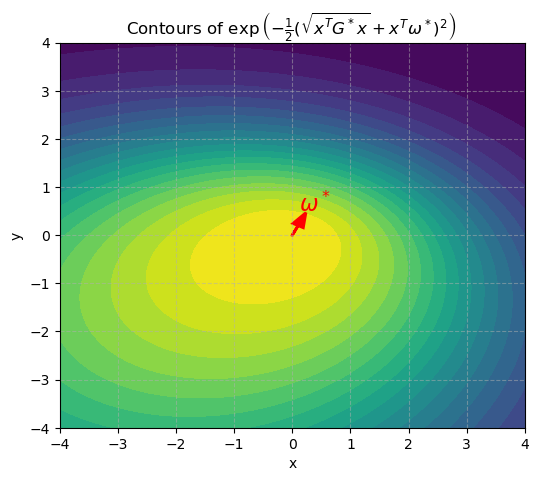

In [3]:
# If w and M are torch tensors, convert to numpy. 
# If they're already numpy arrays, leave them as is.
if hasattr(w_star, "numpy"):
    w_star = w_star.numpy()
if hasattr(G_star, "numpy"):
    G_star = G_star.numpy()

# Make a grid of (x, y) points
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
XY = np.stack([X, Y], axis=-1)  # shape (200, 200, 2)

# Compute sqrt(x^T M x) for each point in the grid
norm_G_star_XY = np.sqrt(np.einsum('...i,ij,...j->...', XY, G_star, XY))

# Compute x^T w for each point
dot_XY_w_star = XY @ w_star
Z = np.exp(-0.5 * (norm_G_star_XY + dot_XY_w_star) ** 2)

plt.figure(figsize=(6, 5))
contourf = plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.xlabel("x")
plt.title(r"Contours of $\exp\left(-\frac{1}{2}(\sqrt{x^T G^* x} + x^T \omega^*)^2\right)$ ")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True, alpha=0.5, linestyle="--")
# Add an arrow to indicate the direction of w and display the label using annotate
arrow_start = np.array([0.0, 0.0])  # arrow starts at the origin
plt.arrow(
    arrow_start[0],
    arrow_start[1],
    w_star[0],
    w_star[1],
    head_width=0.2,
    head_length=0.3,
    fc="red",
    ec="red",
    linewidth=2,
)
# Add a label with LaTeX at the arrow tip
arrow_tip = arrow_start + w_star
plt.annotate(
    r"$\omega^*$",
    xy=(arrow_tip[0], arrow_tip[1]),
    xytext=(arrow_tip[0]+0.3, arrow_tip[1]+0.3),
    color="red",
    fontsize=16,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="red", linewidth=0),  # invisible arrow for alignment
    ha='center'
)

## KDE plot with MCMC sampling

In [4]:
w_star = torch.tensor([0.1, 0.2])

G_star = torch.tensor([[0.1, 0.], 
              [0.0, 0.2]])

In [5]:
def ll(z : Tensor, G_star : Tensor, w_star : Tensor) -> Tensor : 
    """Computes the log likelihood for the initial momentum distribution

    Args:
        z (Tensor): (Batch of) entries of shape (b, d)
        M (Tensor): Metric matrix of shape (d,d)
        w (Tensor): Randers covector of shape (d,)

    Returns:
        Tensor: (Batch of) log likelihood of shape (b,d)
    """
    norm_z = torch.sqrt(torch.einsum("bi,bj,ij->b",z,z,G_star))
    omega_z = z @ w_star
    return -0.5 * (norm_z + omega_z)**2

def momentum_mcmc_sampler(z0 : Tensor, l : int, sigma : float, G_star : Tensor, w_star : Tensor, return_acceptance : bool = False )-> Tensor :
    """
    Performs l steps of a symmetric random walk Metropolis sampler for the momentum distribution
    Args:
        z0 (Tensor): Initial value/batch of values of shape (b, d).
        l (int): Number of Metropolis steps to perform.
        sigma (float): Proposal standard deviation (step size of the Gaussian random walk).
        M (Tensor): Metric matrix of shape (d, d), positive definite.
        w (Tensor): Randers covector of shape (d,).

    Returns:
        Tensor: Final sample(s) after l Metropolis steps, of shape (b, d).
    """
    z = z0.clone()
    n_accept = 0
    n_total = 0
    L = torch.linalg.cholesky(G_star)
    for _ in range(l): 
        prop = z + sigma * torch.randn_like(z) @ torch.linalg.inv(L).T
        log_alpha = ll(prop, G_star, w_star) - ll(z, G_star, w_star)   # (b,)
        u = torch.log(torch.rand(z.shape[0], device=z.device))  # (b,)
        mask = (u < log_alpha)  # (b,)

        n_accept += mask.sum().item()
        n_total += z.shape[0]

        mask_unsq = mask.unsqueeze(1)
        z = torch.where(mask_unsq, prop, z)

    if return_acceptance:
        acceptance_rate = n_accept / n_total if n_total > 0 else 0.0
        return z, acceptance_rate
    else:
        return z

In [6]:
z0 = torch.randn(10**6, 2)
l = 20
sigma = 1.7
z, acc = momentum_mcmc_sampler(z0, l, sigma, G_star, w_star, return_acceptance= True)
print(acc)

0.4288934


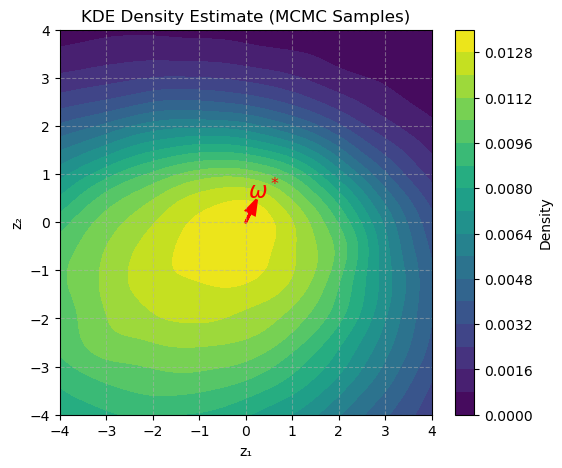

In [7]:
# Convert G_star and w_star to numpy if they are not already
if hasattr(w_star, "numpy"):
    w_star_np = w_star.numpy()
else:
    w_star_np = w_star
if hasattr(G_star, "numpy"):
    G_star_np = G_star.numpy()
else:
    G_star_np = G_star

z_np = z.detach().cpu().numpy()
x, y = z_np[:, 0], z_np[:, 1]

# KDE
kde = gaussian_kde(z_np.T)

# Grid for contours
xgrid = np.linspace(-4, 4, 200)
ygrid = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(xgrid, ygrid)
XY = np.stack([X, Y], axis=-1)  # shape (200, 200, 2)

grid_points = np.vstack([X.ravel(), Y.ravel()])
Z_kde = kde(grid_points).reshape(X.shape)

plt.figure(figsize=(6, 5))
contourf = plt.contourf(X, Y, Z_kde, levels=20, cmap='viridis')
plt.xlabel("z₁")
plt.ylabel("z₂")
plt.title("KDE Density Estimate (MCMC Samples)")
plt.grid(True, alpha=0.5, linestyle="--")
plt.colorbar(contourf, label="Density")

# Add arrow for w_star
arrow_start = np.array([0.0, 0.0])
plt.arrow(
    arrow_start[0],
    arrow_start[1],
    w_star_np[0],
    w_star_np[1],
    head_width=0.2,
    head_length=0.3,
    fc="red",
    ec="red",
    linewidth=2,
)
arrow_tip = arrow_start + w_star_np
plt.annotate(
    r"$\omega^*$",
    xy=(arrow_tip[0], arrow_tip[1]),
    xytext=(arrow_tip[0]+0.3, arrow_tip[1]+0.3),
    color="red",
    fontsize=16,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="red", linewidth=0),
    ha='center'
)
plt.show()

## KDE plot with exact sampler

In [8]:
w_star = torch.tensor([0.1, 0.2])

G_star = torch.tensor([[0.1, 0.], 
              [0.0, 0.2]])

In [9]:
def moebius_transform(u: Tensor, mu: Tensor, rho: Tensor, G_star: Tensor) -> Tensor:
    """
    Applies a Möbius transformation relevant to sampling on Riemannian manifolds.

    Args:
        u (Tensor): Input points of shape (batch_size, d).
        mu (Tensor): Mean direction vector of shape (d,).
        rho (Tensor): Scalar parameter controlling rotation/stretch (tensor scalar).
        M (Tensor): Symmetric positive definite matrix (covariance or metric) of shape (d, d).

    Returns:
        Tensor: Transformed points of shape (batch_size, d) after applying the Möbius transformation.
    """
    inner_prod = (u @ G_star @ mu).unsqueeze(-1) # (batch_size, 1)
    
    num = (1 - rho**2) * (u + rho * mu)
    den = 1 + 2 * rho * inner_prod + rho**2
    return (num / den) + rho * mu

def riemann_sphere_uniform_sampler(batch_size: int, d: int, L: Tensor) -> Tensor:
    """
    Uniformly samples points from the unit sphere with respect to the induced metric defined by L on ℝ^d.

    Args:
        batch_size (int): Number of points to sample.
        d (int): Dimension of the sphere (ambient space dimension).
        L (Tensor): Cholesky factor of a positive-definite matrix (d x d), typically representing the metric.

    Returns:
        Tensor: An array of shape (batch_size, d) containing batch_size points uniformly sampled on the
        L-induced unit sphere.
    """
    z = torch.randn(batch_size, d)
    z_unit = z / torch.linalg.norm(z, dim=-1, keepdim=True)
    
    # Solve L.T @ v = z_unit for the whole batch
    v = torch.linalg.solve_triangular(
        L.mT, 
        z_unit.mT, 
        upper=True
    ).mT
    
    return v


def momentum_exact_sampler(G_star: Tensor, w_star: Tensor, batch_size: int = 1, return_stats: bool = False):
    """
    Samples the initial momentum for the FHMC algorithm, exactly according to distribution induced by kinetic energy.

    Args:
        M (Tensor): The symmetric positive definite metric tensor of shape (d, d).
        w (Tensor): The potential vector of length d, defining the linear drift in momentum space.
        batch_size (int, optional): Number of independent momentum samples to generate. Defaults to 1.
        return_stats (bool, optional): If True, also returns the mean number of proposal iterations per sample. Defaults to False.

    Returns:
        Tensor: Sampled momentum tensor of shape (batch_size, d).
        float (optional): If return_stats is True, average number of iterations per sample is also returned.
    """
    d = G_star.shape[0]

    # Pre-computations
    L = torch.linalg.cholesky(G_star)
    if not w_star.any():
        beta = torch.zeros(1)
        mu = torch.zeros(d)
        rho = torch.zeros(1)
    else:
        G_star_inv = torch.linalg.inv(G_star)
        beta = torch.sqrt(w_star@ G_star_inv @ w_star)
        mu = -G_star_inv @ w_star / beta
        rho = beta / (1 + torch.sqrt(1 - beta**2))
    
    # Initialize containers for the accepted directions u'
    final_u_prime = torch.zeros((batch_size, d))
    accepted_mask = torch.zeros(batch_size, dtype=torch.bool)
    
    if return_stats: 
        iterations_per_sample = torch.zeros(batch_size)
    
    # Acceptance-Rejection for the direction u'
    while not accepted_mask.all():
        active_indices = torch.where(~accepted_mask)[0]
        num_to_sample = len(active_indices)
        
        if return_stats:   
            iterations_per_sample[active_indices] += 1
        
        # Sample u' candidates
        v_subset = riemann_sphere_uniform_sampler(num_to_sample, d, L)
        u_subset = moebius_transform(v_subset, mu, rho, G_star)
        
        # Bernoulli test 
        p = (1 - beta) / (1 + (u_subset @ w_star))
        alpha = torch.rand(num_to_sample) <= p
        
        if alpha.any():
            just_accepted_indices = active_indices[alpha]
            final_u_prime[just_accepted_indices] = u_subset[alpha]
            accepted_mask[just_accepted_indices] = True
            

    # Sample radius
    s = torch.randn(batch_size, d, device=G_star.device).norm(dim=-1)
    r = s / (1 + (final_u_prime @ w_star))
    
    # Final momentum q = r * u'
    final_q = r.unsqueeze(-1) * final_u_prime
    
    if return_stats:
        return final_q, iterations_per_sample.mean().item()
    
    return final_q

In [10]:
num_samples = 10**6
z, mean_iters = momentum_exact_sampler(G_star, w_star, num_samples, return_stats=True)
print(f"Mean number of iterations: {mean_iters}")

Mean number of iterations: 1.5483020544052124


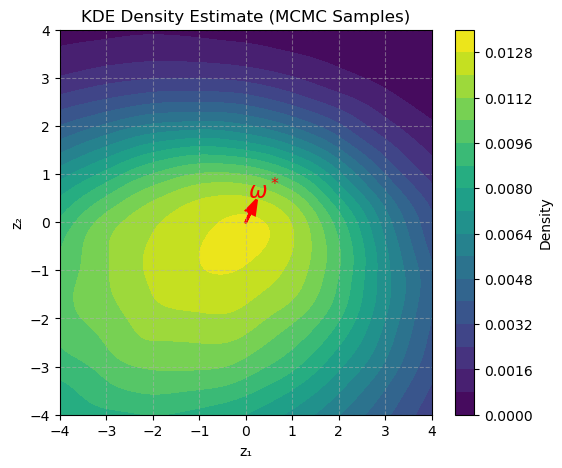

In [11]:
# Convert G_star and w_star to numpy if they are not already
if hasattr(w_star, "numpy"):
    w_star_np = w_star.numpy()
else:
    w_star_np = w_star
if hasattr(G_star, "numpy"):
    G_star_np = G_star.numpy()
else:
    G_star_np = G_star

z_np = z.detach().cpu().numpy()
x, y = z_np[:, 0], z_np[:, 1]

# KDE
kde = gaussian_kde(z_np.T)

# Grid for contours
xgrid = np.linspace(-4, 4, 200)
ygrid = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(xgrid, ygrid)
XY = np.stack([X, Y], axis=-1)  # shape (200, 200, 2)

grid_points = np.vstack([X.ravel(), Y.ravel()])
Z_kde = kde(grid_points).reshape(X.shape)

plt.figure(figsize=(6, 5))
contourf = plt.contourf(X, Y, Z_kde, levels=20, cmap='viridis')
plt.xlabel("z₁")
plt.ylabel("z₂")
plt.title("KDE Density Estimate (MCMC Samples)")
plt.grid(True, alpha=0.5, linestyle="--")
plt.colorbar(contourf, label="Density")

# Add arrow for w_star
arrow_start = np.array([0.0, 0.0])
plt.arrow(
    arrow_start[0],
    arrow_start[1],
    w_star_np[0],
    w_star_np[1],
    head_width=0.2,
    head_length=0.3,
    fc="red",
    ec="red",
    linewidth=2,
)
arrow_tip = arrow_start + w_star_np
plt.annotate(
    r"$\omega^*$",
    xy=(arrow_tip[0], arrow_tip[1]),
    xytext=(arrow_tip[0]+0.3, arrow_tip[1]+0.3),
    color="red",
    fontsize=16,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="red", linewidth=0),
    ha='center'
)
plt.show()

### Dimension dependency test

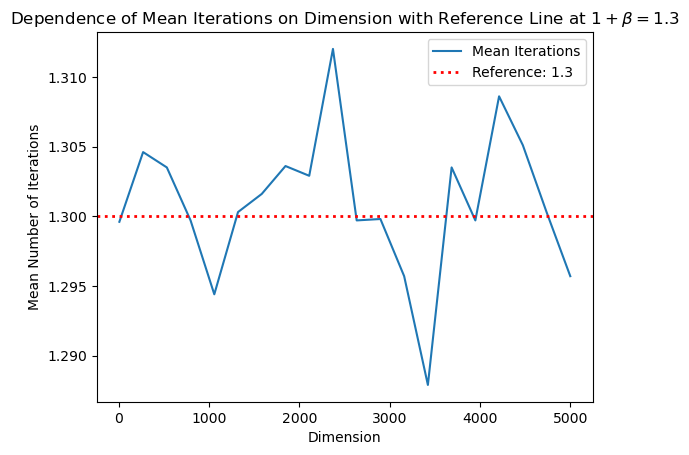

In [12]:
n_dims = 20
dims = torch.linspace(5, 5000, n_dims)
batch_size = 10000
mean_iter = []

for d in dims:
    d = int(d.item())
    w = torch.zeros(d)
    w[0] = 0.3
    M = torch.eye(d)
    mean_iter.append(momentum_exact_sampler(M, w, batch_size, True)[1])

plt.plot(dims, mean_iter, label="Mean Iterations")
plt.axhline(1.3, color='r', linestyle=':', linewidth=2, label="Reference: 1.3")
plt.xlabel("Dimension")
plt.ylabel("Mean Number of Iterations")
plt.title(r"Dependence of Mean Iterations on Dimension with Reference Line at $1+\beta = 1.3$")
plt.legend()
plt.show()